In [25]:
# Basic Import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Modelling
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
import warnings




In [26]:
# Import the CSV Data as Pandas DataFrame
df = pd.read_csv("C:/Users/phani/Downloads/StudentsPerformance_3_lyst1729690388778.csv")

In [27]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [28]:
x=df.drop(columns=['math score'],axis=1)

In [29]:
x.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93
3,male,group A,associate's degree,free/reduced,none,57,44
4,male,group C,some college,standard,none,78,75


In [30]:
y=df['math score']

In [31]:
y.head()

0    72
1    69
2    90
3    47
4    76
Name: math score, dtype: int64

In [33]:
# Creation of transformer columns:
num_cols = x.select_dtypes(exclude="object").columns
cat_cols = x.select_dtypes(include="object").columns




In [35]:
#perform OneHotEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

num_trans = StandardScaler()
oh_tran = OneHotEncoder()

preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder", oh_tran, cat_cols),
        ("StandardScaler", num_trans, num_cols),
    ]
)

x = preprocessor.fit_transform(x)

In [36]:
x.shape

(1000, 19)

In [37]:
# separating Train and test for the data:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, Y, test_size=0.2, random_state=23)




In [38]:

# creating an evaluate function to give all metrics after model training:
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2 = r2_score(true, predicted)
    return mae, mse, rmse, r2


In [58]:
# loading models
models = {
    "LR": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "KNN": KNeighborsRegressor(),
    "DT": DecisionTreeRegressor(),
    "RF": RandomForestRegressor()
}

# model performance
model_list = []
r2_list = []

for i in range(len(list(models))):
    
    model = list(models.values())[i]

    # Train model
    model.fit(x_train, y_train)

    # Make predictions
    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)

    # Evaluate Train and Test dataset
    model_train_mae, model_train_mse, model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)

    model_test_mae, model_test_mse, model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)

    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])

    print('Model performance for Training set')
    print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("- R2 Score: {:.4f}".format(model_train_r2))

    print('---------------------------------------------')

    print('Model performance for Test set')
    print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_test_mae))
    print("- R2 Score: {:.4f}".format(model_test_r2))

    r2_list.append(model_test_r2)

print('=' * 35)

LR
Model performance for Training set
- Root Mean Squared Error: 5.2592
- Mean Absolute Error: 4.1681
- R2 Score: 0.8815
---------------------------------------------
Model performance for Test set
- Root Mean Squared Error: 5.6218
- Mean Absolute Error: 4.5734
- R2 Score: 0.8524
Lasso
Model performance for Training set
- Root Mean Squared Error: 6.5500
- Mean Absolute Error: 5.1997
- R2 Score: 0.8162
---------------------------------------------
Model performance for Test set
- Root Mean Squared Error: 6.5967
- Mean Absolute Error: 5.1005
- R2 Score: 0.7967
Ridge
Model performance for Training set
- Root Mean Squared Error: 5.2594
- Mean Absolute Error: 4.1672
- R2 Score: 0.8815
---------------------------------------------
Model performance for Test set
- Root Mean Squared Error: 5.6191
- Mean Absolute Error: 4.5672
- R2 Score: 0.8525


C:\Users\phani\anaconda3\1\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\phani\anaconda3\1\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\phani\anaconda3\1\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\phani\anaconda3\1\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^

KNN
Model performance for Training set
- Root Mean Squared Error: 5.7669
- Mean Absolute Error: 4.5672
- R2 Score: 0.8575
---------------------------------------------
Model performance for Test set
- Root Mean Squared Error: 7.1104
- Mean Absolute Error: 5.7230
- R2 Score: 0.7638
DT
Model performance for Training set
- Root Mean Squared Error: 0.1250
- Mean Absolute Error: 0.0063
- R2 Score: 0.9999
---------------------------------------------
Model performance for Test set
- Root Mean Squared Error: 8.6937
- Mean Absolute Error: 6.9400
- R2 Score: 0.6470
RF
Model performance for Training set
- Root Mean Squared Error: 2.2500
- Mean Absolute Error: 1.7542
- R2 Score: 0.9783
---------------------------------------------
Model performance for Test set
- Root Mean Squared Error: 6.4846
- Mean Absolute Error: 5.1485
- R2 Score: 0.8036


In [59]:
# Results summary table
pd.DataFrame(
    list(zip(model_list, r2_list)),
    columns=['Model Name', 'R2_Score']
).sort_values(by=['R2_Score'], ascending=False)


,Model Name,R2_Score
2,Ridge,0.852517
0,LR,0.852377
5,RF,0.803584
1,Lasso,0.796734
3,KNN,0.763845
4,DT,0.646966


In [61]:
lin_model = LinearRegression(fit_intercept=True)
lin_model = lin_model.fit(x_train, y_train)
y_pred = lin_model.predict(x_test)
score = r2_score(y_test, y_pred) * 100
print("Accuracy of the model is %.2f" % score)


Accuracy of the model is 85.24


Text(0.5, 1.0, 'Actual vs Predicted Values')

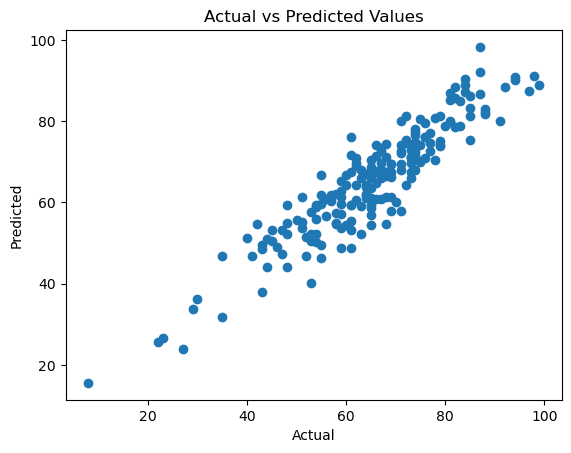

In [63]:
#linear regression
plt.scatter(y_test, y_pred)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted Values')


Text(0.5, 1.0, 'Regression Plot: Actual vs Predicted')

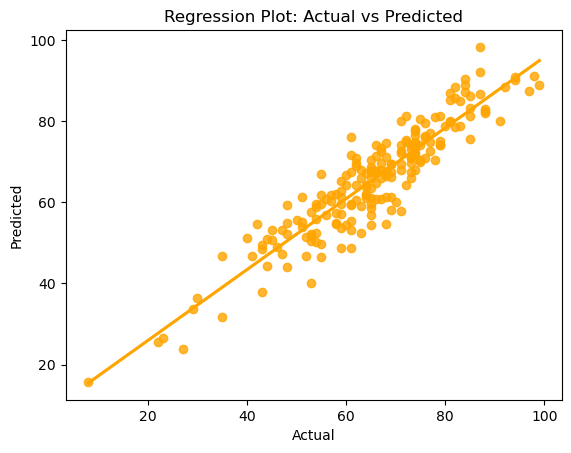

In [65]:
sns.regplot(x=y_test, y=y_pred, ci=None, color='orange')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Regression Plot: Actual vs Predicted')
